In [1]:
import pandas as pd

from cleanskate import Dataset

ds = Dataset()

officials = ds.load_officials()
panel = ds.load_segment_officials()

panel = panel[ panel['role'].str.startswith('Judge') ]

ISU does not report nationality for all events, with all judges being listed as nationality "ISU" for some events. We can still recover some of this information by looking at other nationalities the same person has been listed under. 

In [2]:
isu_panel = panel[ panel['nation'] == 'ISU' ].drop(columns='nation')
non_isu_panel = panel[ panel['nation'] != 'ISU' ]

# for judges listed as ISU, merge in other nationalities
# judges that are only ever listed as ISU will be dropped
inferred_nationalities = panel[ panel['nation'] != 'ISU' ][['name', 'nation']].drop_duplicates()
isu_panel = pd.merge(isu_panel, inferred_nationalities, how='inner')

panel = pd.concat([non_isu_panel, isu_panel])
panel

,event_label,segment_label,role,panel_position,name,nation
4,International Cranberry Cup 2025,Men SP,Judge No.1,1.0,Lise Rosto JENSEN,NOR
5,International Cranberry Cup 2025,Men SP,Judge No.2,2.0,Chihee RHEE,KOR
6,International Cranberry Cup 2025,Men SP,Judge No.3,3.0,Lorrie PARKER,USA
7,International Cranberry Cup 2025,Men SP,Judge No.4,4.0,Cynthia BENSON,CAN
8,International Cranberry Cup 2025,Men SP,Judge No.5,5.0,Saara EHALT,FIN
...,...,...,...,...,...,...
1908,Junior Worlds 2026,Junior Ice Dance FD,Judge No.5,5.0,Elyse MATSUMOTO,USA
1909,Junior Worlds 2026,Junior Ice Dance FD,Judge No.6,6.0,Larissa SHULJATEVA,EST
1910,Junior Worlds 2026,Junior Ice Dance FD,Judge No.7,7.0,Lucy LEONARD,GBR
1911,Junior Worlds 2026,Junior Ice Dance FD,Judge No.8,8.0,Ronald BEAU,FRA


We now need to combine the judges scores with the elements and extract the score from each judge.

In [ ]:
import numpy as np

elements = ds.load_elements()

elements = elements[ elements['scored_element']]

# combine with judge data
panel['judge_index'] = panel['panel_position'].apply(lambda x: int(x) - 1)
panel_for_merging = panel[['event_label', 'segment_label', 'name', 'nation', 'judge_index']].rename(
    columns={'name': 'judge_name', 'nation': 'judge_nationality'}
    )

elements_with_scores = pd.merge(
    elements, 
    panel_for_merging, 
    on=['event_label', 'segment_label'], 
    how='inner'
    )

elements_with_scores = elements_with_scores.rename(columns={'judge_scores': 'all_judge_scores'})
elements_with_scores['judge_score'] = elements_with_scores.apply(
    lambda x: x.all_judge_scores[x.judge_index],
    axis=1
    )
elements_with_scores['other_judges_mean_score'] = elements_with_scores.apply(
    lambda x: np.mean([s for i, s in enumerate(x.all_judge_scores) if i != x.judge_index]),
    axis=1
    )


/var/folders/1b/fchfpj114g76vsyfvbb7rbsm0000gn/T/ipykernel_27244/3123396049.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#899BB8'` for the same effect.

  ax = sns.boxplot(


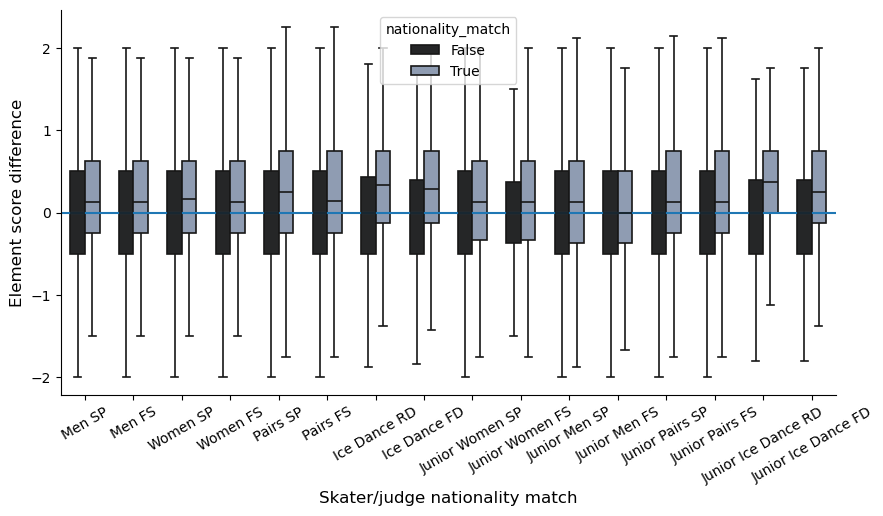

In [4]:
import matplotlib as mpl
import seaborn as sns
import numpy as np

mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

elements_with_scores['judge_difference'] = elements_with_scores['judge_score'] - elements_with_scores['other_judges_mean_score']
elements_with_scores['nationality_match'] = elements_with_scores['noc'] == elements_with_scores['judge_nationality']

mpl.pyplot.figure(figsize=(10, 5))
ax = sns.boxplot(
    elements_with_scores,
    x='segment_label',
    y='judge_difference',
    hue='nationality_match',
    width=0.6,
    fliersize=3,
    linewidth=1.2,
    color="#899BB8",
    showfliers=False
    )
mpl.pyplot.axhline(y=0, ) 

ax.set_xlabel("Skater/judge nationality match", fontsize=12)
ax.set_ylabel("Element score difference", fontsize=12)
ax.tick_params(axis='x', rotation=30)

In [ ]:
components = ds.load_program_components()
components_with_scores = pd.merge(
    components, 
    panel_for_merging, 
    on=['event_label', 'segment_label'], 
    how='inner'
    )

components_with_scores


Help on function axhline in module matplotlib.pyplot:

axhline(y: 'float' = 0, xmin: 'float' = 0, xmax: 'float' = 1, **kwargs) -> 'Line2D'
    Add a horizontal line spanning the whole or fraction of the Axes.

    Note: If you want to set x-limits in data coordinates, use
    `~.Axes.hlines` instead.

    Parameters
    ----------
    y : float, default: 0
        y position in :ref:`data coordinates <coordinate-systems>`.

    xmin : float, default: 0
        The start x-position in :ref:`axes coordinates <coordinate-systems>`.
        Should be between 0 and 1, 0 being the far left of the plot,
        1 the far right of the plot.

    xmax : float, default: 1
        The end x-position in :ref:`axes coordinates <coordinate-systems>`.
        Should be between 0 and 1, 0 being the far left of the plot,
        1 the far right of the plot.

    Returns
    -------
    `~matplotlib.lines.Line2D`
        A `.Line2D` specified via two points ``(xmin, y)``, ``(xmax, y)``.
        Its tran

In [6]:
elements.columns

Index(['event_label', 'event_series', 'event_level', 'segment_label', 'name',
       'noc', 'element_number', 'element_code', 'attempt_code',
       'element_family', 'scored_element', 'clean_element', 'fall',
       'fall_inferred', 'invalid_element', 'call_quarter', 'call_underrotated',
       'call_downgraded', 'call_edge_attention', 'call_wrong_edge',
       'info_flags', 'base_value', 'bonus_points', 'second_half_bonus', 'goe',
       'panel_score', 'judge_scores'],
      dtype='str')